# RAG, векторная база и память агента

На первом этапе ReAct агент ходил за фактами в живую Википедию и отвечал на 58 процентов свежих вопросов. Теперь кладём знания рядом: режем корпус на куски, считаем эмбеддинги, ищем сначала на numpy, потом в Milvus, собираем RAG-ответ с источниками, разбираем провалы и даём агенту память. В конце превращаем поиск в инструмент агента.

Тезис тот же: 

**Хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** 

Хотим ответить на вопрос: 

**Сколько стоит верный ответ, когда знания лежат в индексе, и сколько в этой цене занимает контекст.**


## Что нужно для воспроизведения

**Ключ** OpenRouter: локально файл `.env` в корне репозитория, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). 

**Данные**: в папке `data` в корне репозитория, в Kaggle датасет `ai-agent-events-data` и включённый Internet.

**Milvus** в Docker: в корне репозитория лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел [«Без Docker и в Kaggle»](../README.md#без-docker-и-в-kaggle).

In [1]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # ноутбук лежит в notebooks/
DATA = next((p for p in [ROOT / "data", Path("/kaggle/input/ai-agent-events-data"), Path("/kaggle/input/ai-agent-events-data/data")]
             if (p / "corpus_2026.jsonl").exists()), ROOT / "data")
IMG = ROOT / "img" / "02"
IMG.mkdir(parents=True, exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Спринт 1. Корпус и нарезка

Корпус - 28 обзорных страниц Википедии про 2026 год, 830 тысяч символов + страницы с новостями по интересам. Вопросы те же, что на первом этапе: 124 штуки, на которых Sonnet без инструментов выдает низкий процент решения + 30 вопросов по интересам. У каждого вопроса есть поле `evidence`, исходная строка с ответом, поэтому мы точно знаем, какой кусок верный, и сможем считать качество поиска без ручной разметки.

Страница устроена как список датированных событий: одна строка, одно событие. Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По структуре: одна строка это один кусок, а заголовок раздела (месяц) едет с куском как метаданные.

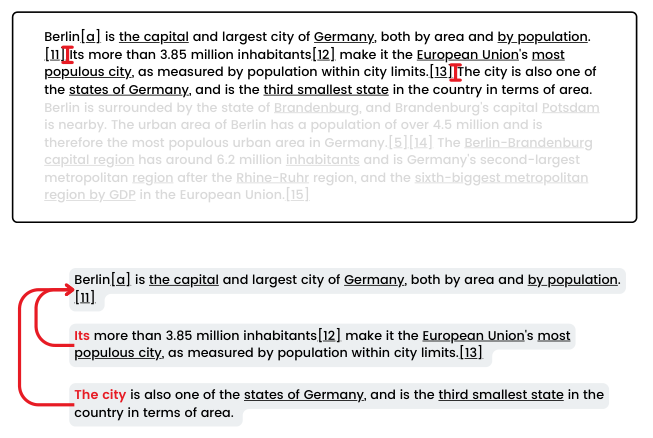

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [2]:
# Корпус собирает scripts/fetch_corpus.py: берёт готовые страницы из data/corpus_2026.jsonl и докачивает недостающие.
# Повторный запуск ничего не скачивает. В Kaggle скрипта нет, там корпус уже собран в датасете.
script = ROOT / "scripts" / "fetch_corpus.py"
if script.exists():
    !{sys.executable} {script}


страниц: 50 (скачано сейчас: 0), символов: 1223573, содержательных строк: 7390
вопросов с цитатой, найденной в корпусе: 154 из 155
  нет цитаты: fresh-6 [2026] August 26 – 2026 Nepal–Tibet floods: At least 1,130 people are killed and nearly 4,500 reported miss


### Проверка цитат

У каждого вопроса есть цитата `evidence`: строка из источника, в которой лежит ответ. По ней определяется верный кусок при подсчёте recall@k, поэтому цитата должна дословно находиться в корпусе. Скрипт выше проверяет это для всех вопросов и печатает те, у которых цитата не нашлась.

При первой сборке корпуса цитата не нашлась у 10 вопросов из 155. Девять из них исправлены так, что вопрос и эталонный ответ остались прежними:

| Вопрос | Почему цитата не нашлась | Что сделано |
|---|---|---|
| `fresh-130`, `131`, `136`, `138`, `142`, `145` | Цитата была пересказом, а не дословной строкой | Цитата заменена на дословную строку со страницы |
| `fresh-135` | Ответ есть только в таблице результатов | Цитата заменена на строку таблицы |
| `fresh-153` | Факт о падении на тулупе есть в статье о фигуристке, а не на странице турнира | Страница заменена на «Петросян, Аделия Тиграновна» |
| `fresh-154` | Баллов фигуристки нет на странице турнира | Страница заменена на «Alysa Liu» |
| `fresh-6` | Статью в Википедии обновили: вместо 4,500 пропавших теперь 6,650 | Не исправлен, во втором этапе не участвует |

На первом этапе цитата и страница не использовались: ответ агента сверялся только с эталоном. Поэтому правки не меняют его результаты. `fresh-6` оставлен как есть, чтобы не менять эталон и прогоны первого этапа, и во втором этапе участвуют 154 вопроса.